In [16]:
import pandas as pd

market = pd.read_csv('market.csv')

market.head()


,Date,spf_adj_close,jpm_adj_close,jpm_volume,bac_adj_close,bac_volume,msft_adj_close,msft_volume,jnj_adj_close,jnj_volume,...,wfc_30d_ma,wfc_rsi,citi_10d_ma,citi_20d_ma,citi_30d_ma,citi_rsi,jpm_hist_vol_10,jpm_hist_vol_30,jpm_hist_vol_50,jpm_hist_vol_100
0,8/18/2023,563.68,148.97,8517460,29.11,31430361,320.40,20698864,172.39,85594288,...,41.771333,64.648438,41.444,41.5285,41.495000,72.554348,15.741,16.794,17.201,21.070
1,8/17/2023,564.39,148.63,9953912,29.28,37202231,321.86,16966285,172.94,88924923,...,41.825000,72.270742,41.561,41.5160,41.539333,73.066667,16.191,16.849,17.200,21.071
2,8/16/2023,567.22,150.19,6978235,29.29,47220396,324.04,18836139,173.44,64036947,...,41.868667,64.150943,41.688,41.4910,41.587333,69.300912,15.964,16.583,17.091,21.421
3,8/15/2023,568.42,150.83,10300303,29.94,43406068,321.01,24355491,173.85,45905612,...,41.931000,64.066194,41.837,41.5330,41.679000,74.025974,16.948,16.856,17.037,21.579
4,8/14/2023,578.82,154.77,5044282,30.93,32563693,322.93,20113725,172.17,48213840,...,42.034000,70.370370,42.115,41.6540,41.808333,77.827051,11.697,15.349,16.012,21.117


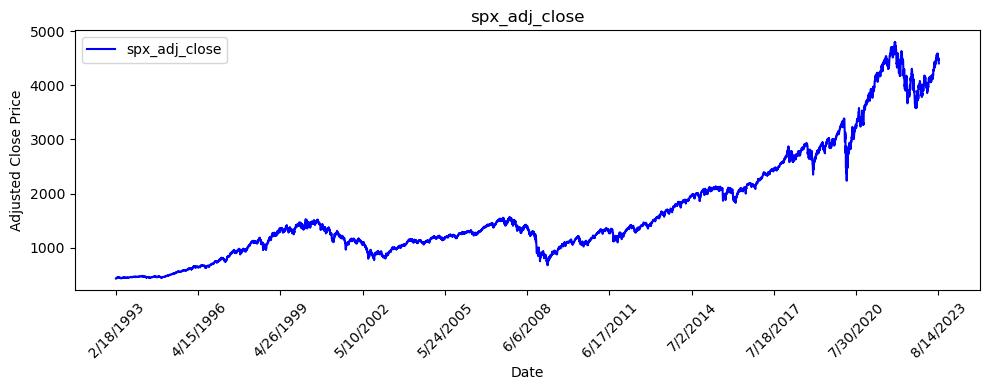

In [17]:
# Plotting SPX price with reversed dates
import matplotlib.pyplot as plt

# Create plot for SPX only
plt.figure(figsize=(10, 4))
plt.plot(market['Date'][::-1], market['spx_adj_close'][::-1], label='spx_adj_close', color='blue')
plt.title('spx_adj_close')
plt.xlabel('Date') 
plt.ylabel('Adjusted Close Price')
plt.xticks(market['Date'][::-1][::len(market) // 10], rotation=45)  # Show only a subset of dates for clarity
plt.legend()
plt.tight_layout()
plt.show()

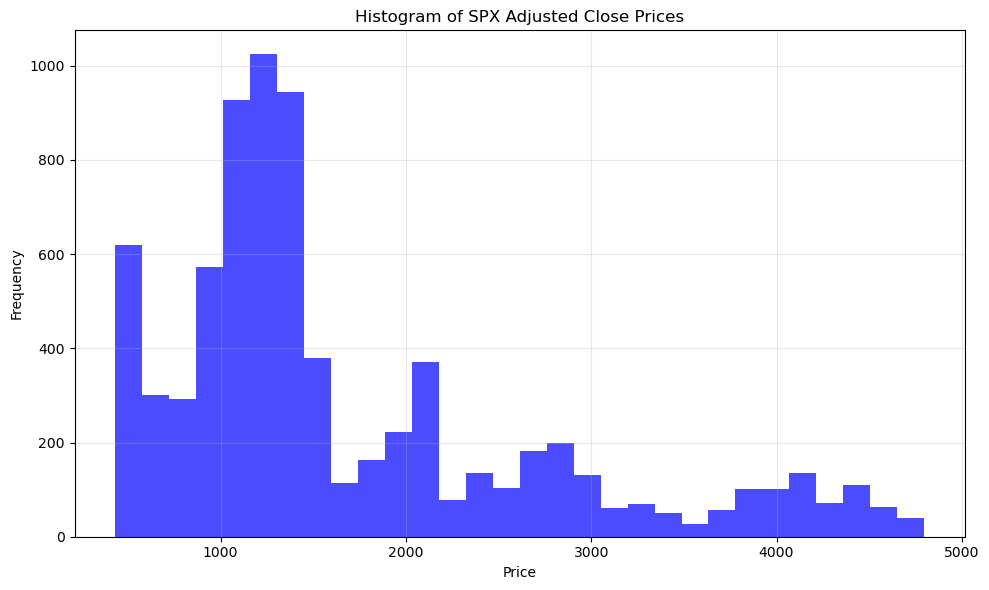

In [18]:
# Create histogram of SPX adjusted close prices
plt.figure(figsize=(10, 6))
plt.hist(market['spx_adj_close'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of SPX Adjusted Close Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
# Calculate the median and MAD
median = market['spx_adj_close'].median()
mad = (market['spx_adj_close'] - median).abs().median()  # Corrected this line
threshold = 3 * mad  # Using 3 as a common multiplier for outlier detection

# Identifying outliers
outliers = market[abs(market['spx_adj_close'].astype(float) - median) > threshold]

# Print summary of outliers found
print(f"Number of outliers detected: {len(outliers)}")
if len(outliers) > 0:
    print("\nOutlier dates and values:")
    print(outliers[['Date', 'spx_adj_close']])
    
    # Calculate rolling median and MAD with a 30-day window
    rolling_median = market['spx_adj_close'].rolling(window=30, center=True).median()
    rolling_mad = (market['spx_adj_close'] - rolling_median).abs().rolling(window=30, center=True).median()
    rolling_threshold = 4 * rolling_mad
    
    # Identify outliers using rolling statistics
    rolling_outliers = market[abs(market['spx_adj_close'] - rolling_median) > rolling_threshold]
    
    print("\nOutliers using 30-day rolling window:")
    print(f"Number of rolling outliers detected: {len(rolling_outliers)}")
    if len(rolling_outliers) > 0:
        print("\nRolling outlier dates and values:")
        print(rolling_outliers[['Date', 'spx_adj_close']])

Number of outliers detected: 1445

Outlier dates and values:
            Date  spx_adj_close
0      8/18/2023        4404.33
1      8/17/2023        4437.86
2      8/16/2023        4489.72
3      8/15/2023        4464.05
4      8/14/2023        4468.83
...          ...            ...
1467  10/18/2017        2557.64
1468  10/17/2017        2553.17
1469  10/16/2017        2550.93
1470  10/13/2017        2555.24
1474   10/9/2017        2552.07

[1445 rows x 2 columns]

Outliers using 30-day rolling window:
Number of rolling outliers detected: 261

Rolling outlier dates and values:
            Date  spx_adj_close
57     5/26/2023        4115.24
77     4/28/2023        4055.99
233    9/14/2022        4110.41
250    8/19/2022        4274.04
251    8/18/2022        4305.20
...          ...            ...
7403    2/3/1994         479.62
7404    2/2/1994         481.61
7477  10/19/1993         469.50
7494   9/23/1993         452.95
7548    7/8/1993         441.43

[261 rows x 2 columns]


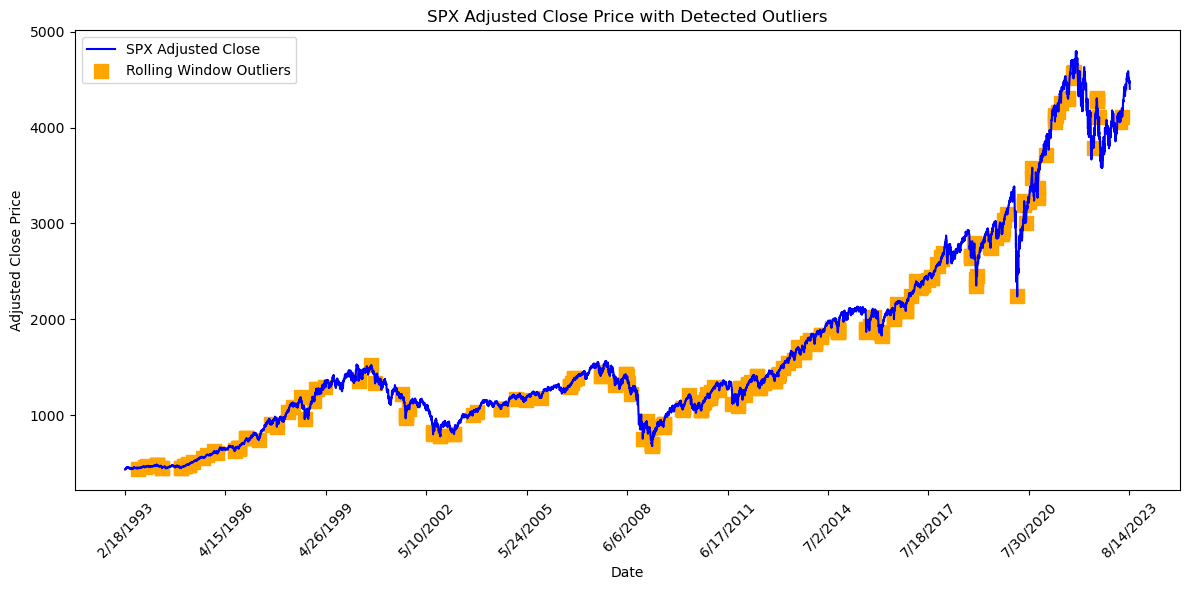

In [20]:

# Create a visualization of the time series with outliers marked
plt.figure(figsize=(12, 6))

# Plot the original SPX data
plt.plot(market['Date'][::-1], market['spx_adj_close'][::-1], label='spx_adj_close', color='blue')
plt.scatter(rolling_outliers['Date'], rolling_outliers['spx_adj_close'], 
           color='orange', marker='s', s=100, label='Rolling Window Outliers')

plt.title('SPX Adjusted Close Price with Detected Outliers')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend(['SPX Adjusted Close', 'Rolling Window Outliers'])
plt.xticks(market['Date'][::-1][::len(market) // 10], rotation=45)
plt.tight_layout()
plt.show()


C:\Users\eddie\AppData\Local\Temp\ipykernel_26836\842390286.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market_2016['Date'] = pd.to_datetime(market_2016['Date'])  # Ensure date format is datetime


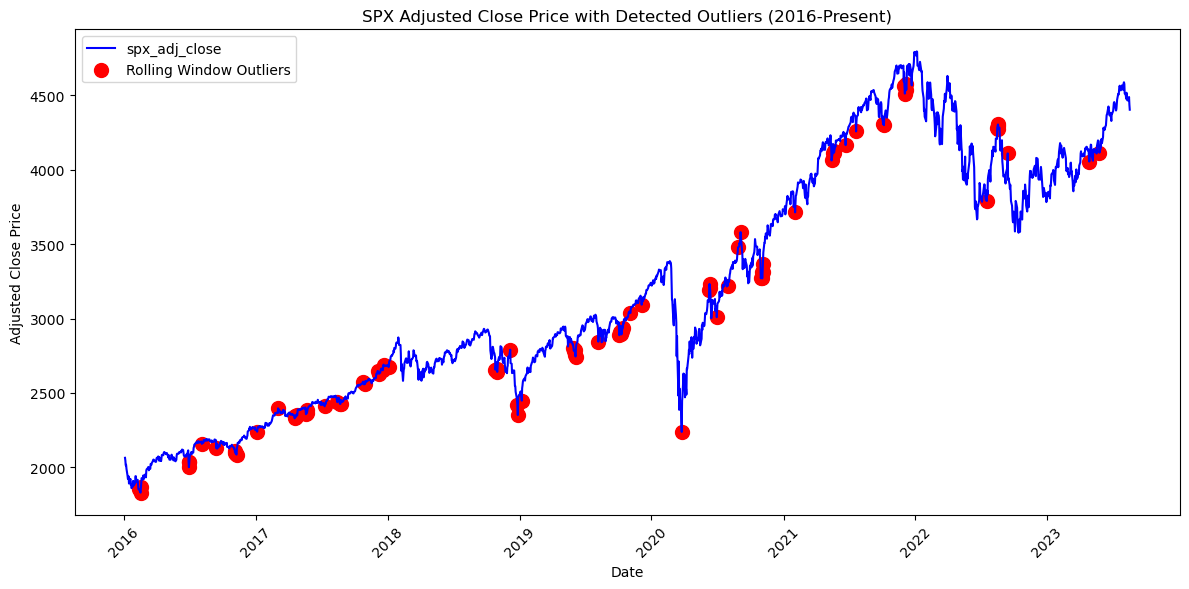


Number of outliers detected (2016-Present): 86

Outlier dates and values:
           Date  spx_adj_close
1889 2016-02-12        1851.86
1888 2016-02-16        1829.08
1887 2016-02-17        1864.78
1795 2016-06-28        2037.41
1794 2016-06-29        2000.54
...         ...            ...
251  2022-08-18        4305.20
250  2022-08-19        4274.04
233  2022-09-14        4110.41
77   2023-04-28        4055.99
57   2023-05-26        4115.24

[86 rows x 2 columns]


In [21]:
# Filter data from 2016 onwards
market_2016 = market[pd.to_datetime(market['Date']) >= '2016-01-01']
market_2016['Date'] = pd.to_datetime(market_2016['Date'])  # Ensure date format is datetime

# Calculate rolling statistics for filtered data
rolling_median_2016 = market_2016['spx_adj_close'].rolling(window=30, center=True).median()
rolling_mad_2016 = (market_2016['spx_adj_close'] - rolling_median_2016).abs().rolling(window=30, center=True).median()
rolling_threshold_2016 = 4 * rolling_mad_2016

# Identify outliers using rolling statistics
rolling_outliers_2016 = market_2016[abs(market_2016['spx_adj_close'] - rolling_median_2016) > rolling_threshold_2016]

# Create visualization
plt.figure(figsize=(12, 6))

plt.plot(market_2016['Date'][::-1], market_2016['spx_adj_close'][::-1], label='spx_adj_close', color='blue')

# Plot the outliers
plt.scatter(rolling_outliers_2016['Date'], rolling_outliers_2016['spx_adj_close'],
           color='red', marker='o', s=100, label='Rolling Window Outliers')

plt.title('SPX Adjusted Close Price with Detected Outliers (2016-Present)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()

# Set yearly ticks for January of each year
yearly_ticks = pd.date_range(start='2016-01-01', end='2023-12-31', freq='YS')
plt.xticks(yearly_ticks, [d.strftime('%Y') for d in yearly_ticks], rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nNumber of outliers detected (2016-Present): {len(rolling_outliers_2016)}")
if len(rolling_outliers_2016) > 0:
    print("\nOutlier dates and values:")
    print(rolling_outliers_2016[['Date', 'spx_adj_close']].sort_values('Date'))

In [38]:
# Calculate and add moving averages to market dataframe
market['spx_10d_ma'] = market['spx_adj_close'].rolling(window=10).mean()
market['spx_20d_ma'] = market['spx_adj_close'].rolling(window=20).mean() 
market['spx_30d_ma'] = market['spx_adj_close'].rolling(window=30).mean()

# Display first few rows with moving averages
print("\nMarket data with SPX Moving Averages:")
print(market[['spx_adj_close', 'spx_10d_ma', 'spx_20d_ma', 'spx_30d_ma']].head())



Market data with SPX Moving Averages:
   spx_adj_close  spx_10d_ma  spx_20d_ma  spx_30d_ma
0        4404.33         NaN         NaN         NaN
1        4437.86         NaN         NaN         NaN
2        4489.72         NaN         NaN         NaN
3        4464.05         NaN         NaN         NaN
4        4468.83         NaN         NaN         NaN


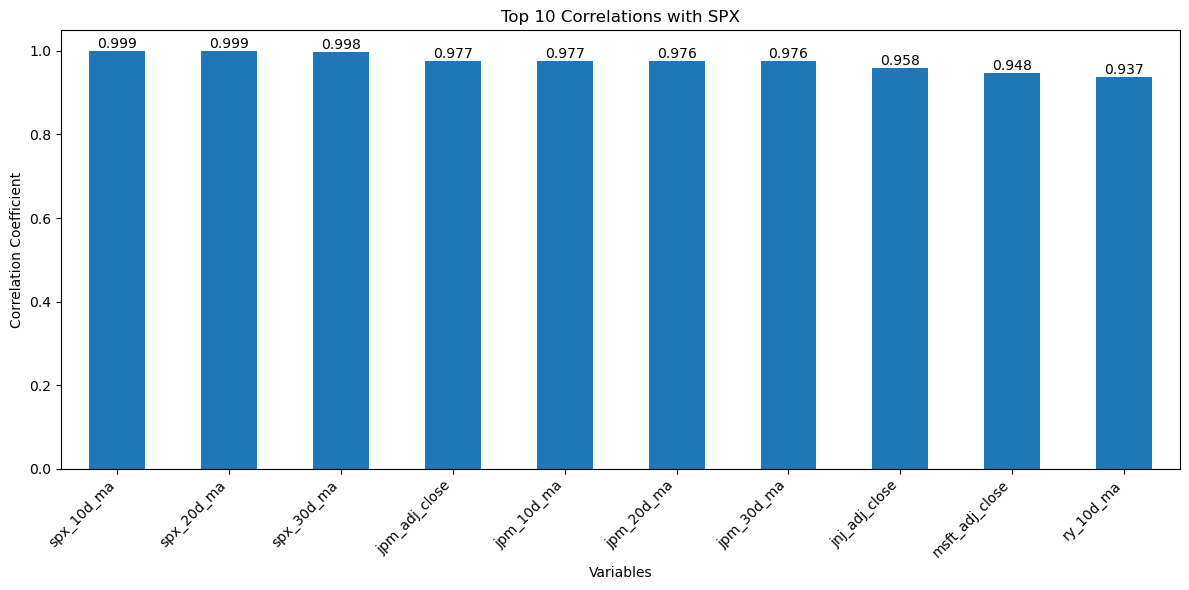


Top 10 correlations with SPX:
spx_10d_ma        0.999430
spx_20d_ma        0.998787
spx_30d_ma        0.998159
jpm_adj_close     0.976938
jpm_10d_ma        0.976765
jpm_20d_ma        0.976423
jpm_30d_ma        0.976108
jnj_adj_close     0.958375
msft_adj_close    0.947730
ry_10d_ma         0.937231
Name: spx_adj_close, dtype: float64


In [39]:
import numpy as np

# Calculate correlations with spx_adj_close
# Select only numeric columns for correlation
numeric_cols = market.select_dtypes(include=[np.number]).columns
correlations = market[numeric_cols].corr()['spx_adj_close'].sort_values(ascending=False)

# Get top 10 correlations (excluding spx_adj_close itself)
top_10_corr = correlations[1:11]

# Create a bar plot
plt.figure(figsize=(12,6))
ax = top_10_corr.plot(kind='bar')
plt.title('Top 10 Correlations with SPX')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(top_10_corr):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the correlation values
print("\nTop 10 correlations with SPX:")
print(top_10_corr)


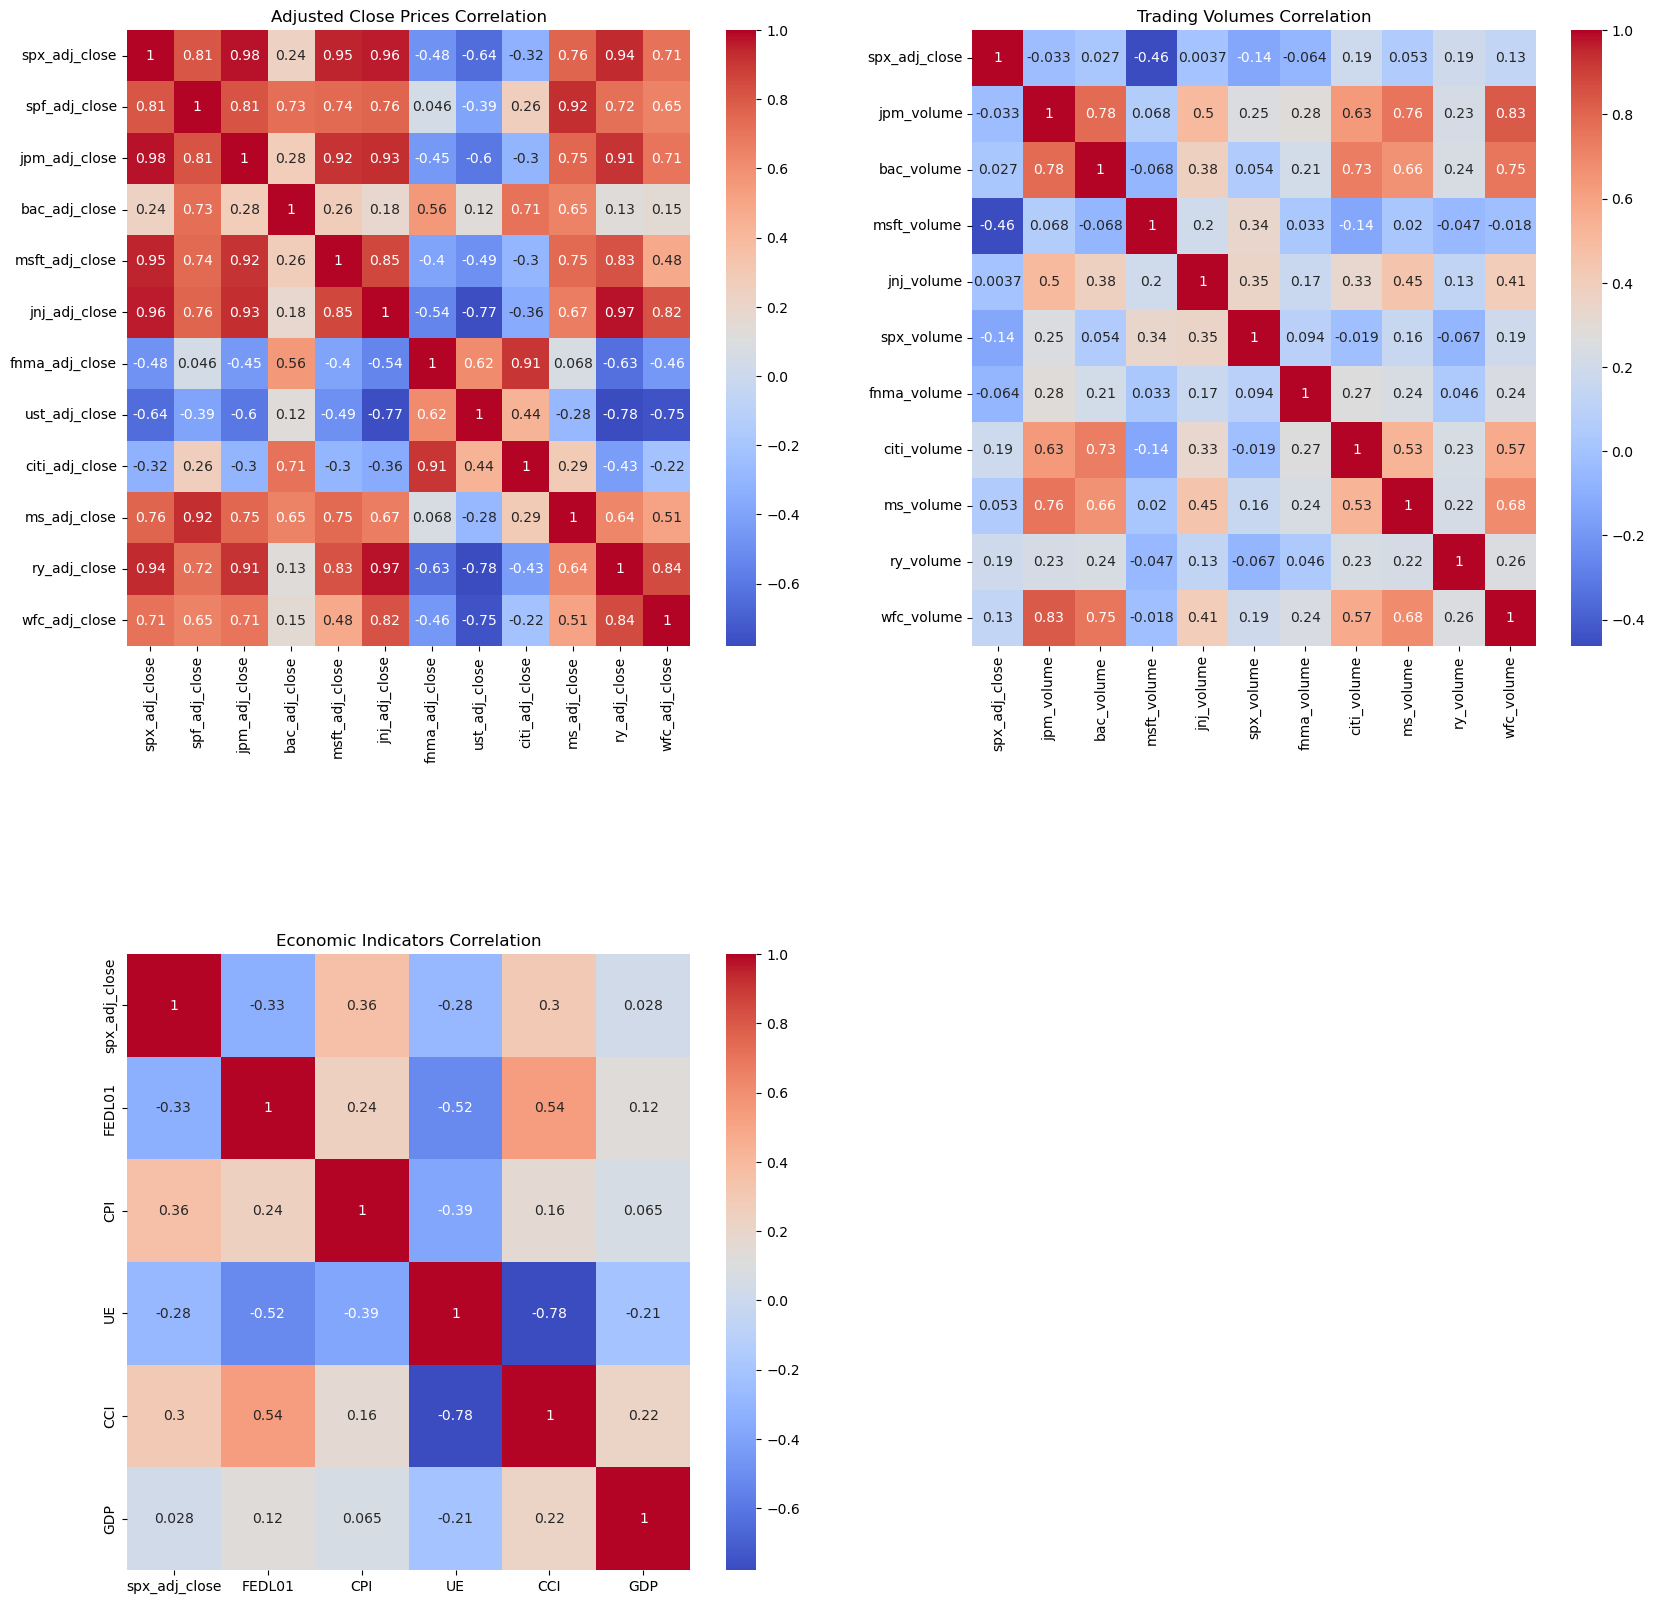

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter columns for each category, making sure to include 'spx_adj_close'
adj_close_columns = ['spx_adj_close'] + [col for col in market.columns if 'adj_close' in col and col != 'spx_adj_close']
volume_columns = ['spx_adj_close'] + [col for col in market.columns if 'volume' in col]
economic_indicators_columns = ['spx_adj_close', 'FEDL01', 'CPI', 'UE', 'CCI', 'GDP']

# Create correlation matrices
adj_close_corr = market[adj_close_columns].corr()
volume_corr = market[volume_columns].corr()
economic_indicators_corr = market[economic_indicators_columns].corr()

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# Adjust space between plots
plt.subplots_adjust(hspace=0.5, wspace=0.2)

# Plotting the heatmaps
sns.heatmap(adj_close_corr, ax=axes[0, 0], annot=True, cmap='coolwarm')
axes[0, 0].set_title('Adjusted Close Prices Correlation')

sns.heatmap(volume_corr, ax=axes[0, 1], annot=True, cmap='coolwarm')
axes[0, 1].set_title('Trading Volumes Correlation')

sns.heatmap(economic_indicators_corr, ax=axes[1, 0], annot=True, cmap='coolwarm')
axes[1, 0].set_title('Economic Indicators Correlation')

# Hide the fourth subplot
axes[1, 1].set_visible(False)

plt.show()

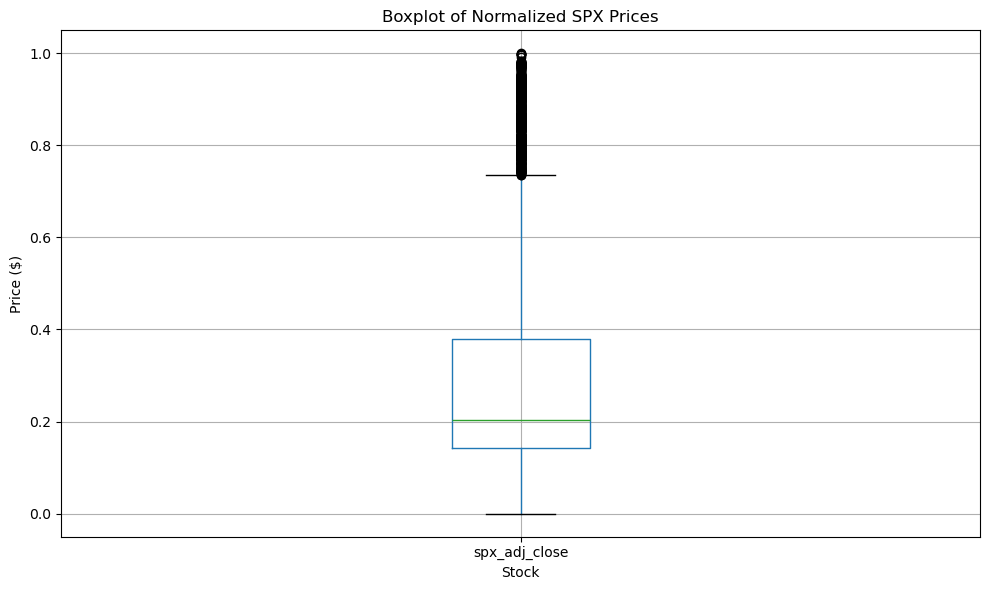

In [9]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Initialize the scaler
scaler = MinMaxScaler()

# Normalize the data
market[['spx_adj_close']] = scaler.fit_transform(market[['spx_adj_close']])

# Plot boxplot for normalized price variable
plt.figure(figsize=(10,6))
market[['spx_adj_close']].boxplot(rot=90)
plt.title('Boxplot of Normalized SPX Prices')
plt.xlabel('Stock')
plt.ylabel('Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Create a copy of the original dataframe
market_normalized = market.copy()

# Get all numeric columns (excluding 'Date' if it exists)
numeric_columns = market.select_dtypes(include=['float64', 'int64']).columns

# Initialize the scaler
scaler = MinMaxScaler()

# Normalize all numeric columns
market_normalized[numeric_columns] = scaler.fit_transform(market[numeric_columns])

# Display first few rows of normalized data
print("\nFirst few rows of normalized data:")
print(market_normalized.head())



First few rows of normalized data:
        Date  spf_adj_close  jpm_adj_close  jpm_volume  bac_adj_close  \
0  8/18/2023       0.793826       0.857797    0.037537       0.501739   
1  8/17/2023       0.794996       0.855678    0.044159       0.505023   
2  8/16/2023       0.799657       0.865403    0.030441       0.505216   
3  8/15/2023       0.801634       0.869393    0.045756       0.517774   
4  8/14/2023       0.818764       0.893956    0.021525       0.536901   

   bac_volume  msft_adj_close  msft_volume  jnj_adj_close  jnj_volume  ...  \
0    0.025284        0.890587     0.020835       0.923096    0.867984  ...   
1    0.029991        0.894674     0.015377       0.926201    0.902212  ...   
2    0.038159        0.900776     0.018111       0.929025    0.646440  ...   
3    0.035049        0.892295     0.026182       0.931340    0.460106  ...   
4    0.026208        0.897669     0.019979       0.921854    0.483828  ...   

   wfc_30d_ma   wfc_rsi  citi_10d_ma  citi_20d_ma  citi_

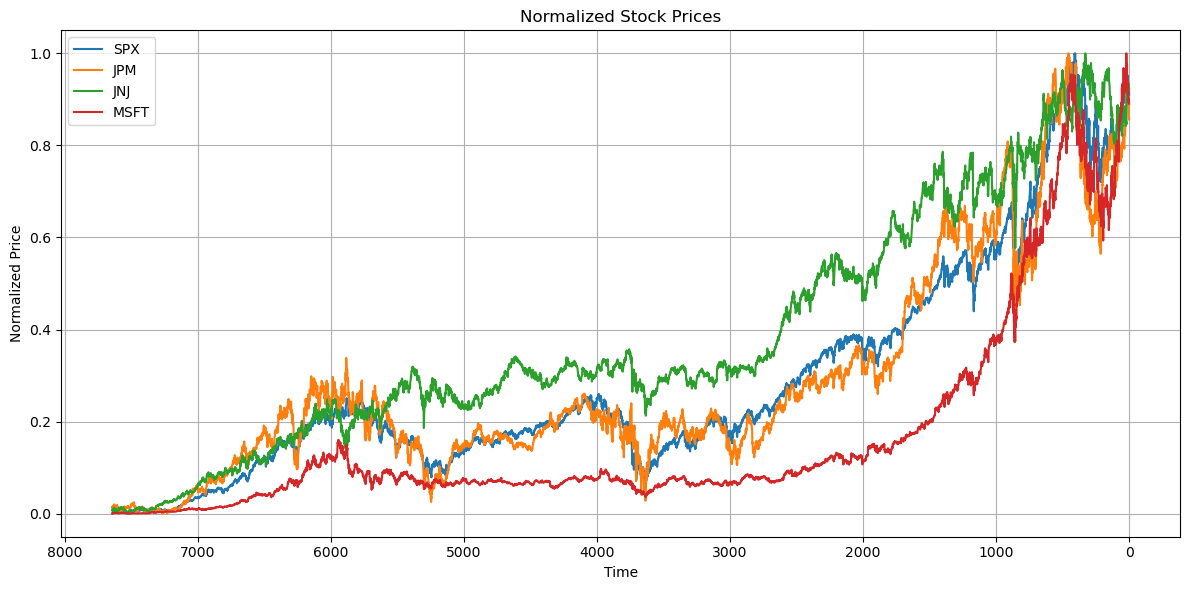

In [12]:
# Plot normalized prices for selected stocks
plt.figure(figsize=(12,6))
plt.plot(market_normalized['spx_adj_close'], label='SPX')
plt.plot(market_normalized['jpm_adj_close'], label='JPM')
plt.plot(market_normalized['jnj_adj_close'], label='JNJ') 
plt.plot(market_normalized['msft_adj_close'], label='MSFT')

plt.title('Normalized Stock Prices')
plt.xlabel('Time')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()  # This line reverses the x-axis
plt.tight_layout()
plt.show()


Prior Parameters for SPX:
Expected Return Prior (μ): -0.000152
Volatility Prior (σ): 0.035935
Inverse-Wishart Prior Parameters:
Degrees of Freedom (ν): 30
Scale Matrix: 0.067384


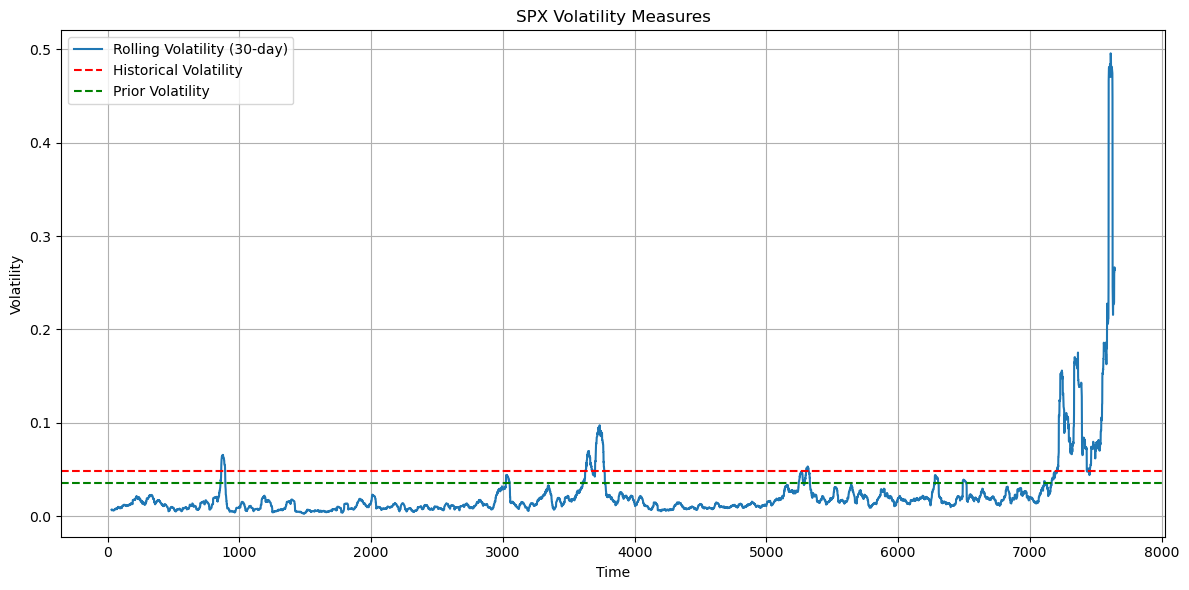

In [58]:
# Calculate historical means and standard deviations for returns
# First calculate daily returns for SPX
spx_returns = market['spx_adj_close'].pct_change().dropna()

# Calculate historical mean return and volatility
spx_mu = spx_returns.mean()
spx_sigma = spx_returns.std()

# Calculate rolling volatility (using 30-day window as an example)
spx_rolling_vol = spx_returns.rolling(window=30).std().dropna()

# Set priors based on historical data
# We'll use the historical mean as our prior for expected returns
# and the average of historical volatility measures as prior for volatility
spx_mu_prior = spx_mu
spx_sigma_prior = (spx_sigma + spx_rolling_vol.mean()) / 2

# Calculate covariance matrix and set inverse-Wishart prior
# For single asset, covariance is just variance
spx_var = spx_returns.var()
nu = 30  # Degrees of freedom parameter (typically set to n+2 where n is dimension)
scale_matrix = spx_var * (nu - 1)  # Scale matrix for inverse-Wishart

print("\nPrior Parameters for SPX:")
print(f"Expected Return Prior (μ): {spx_mu_prior:.6f}")
print(f"Volatility Prior (σ): {spx_sigma_prior:.6f}")
print(f"Inverse-Wishart Prior Parameters:")
print(f"Degrees of Freedom (ν): {nu}")
print(f"Scale Matrix: {scale_matrix:.6f}")

# Visualize the volatility prior
plt.figure(figsize=(12,6))
plt.plot(spx_rolling_vol, label='Rolling Volatility (30-day)')
plt.axhline(y=spx_sigma, color='r', linestyle='--', label='Historical Volatility')
plt.axhline(y=spx_sigma_prior, color='g', linestyle='--', label='Prior Volatility')
plt.title('SPX Volatility Measures')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


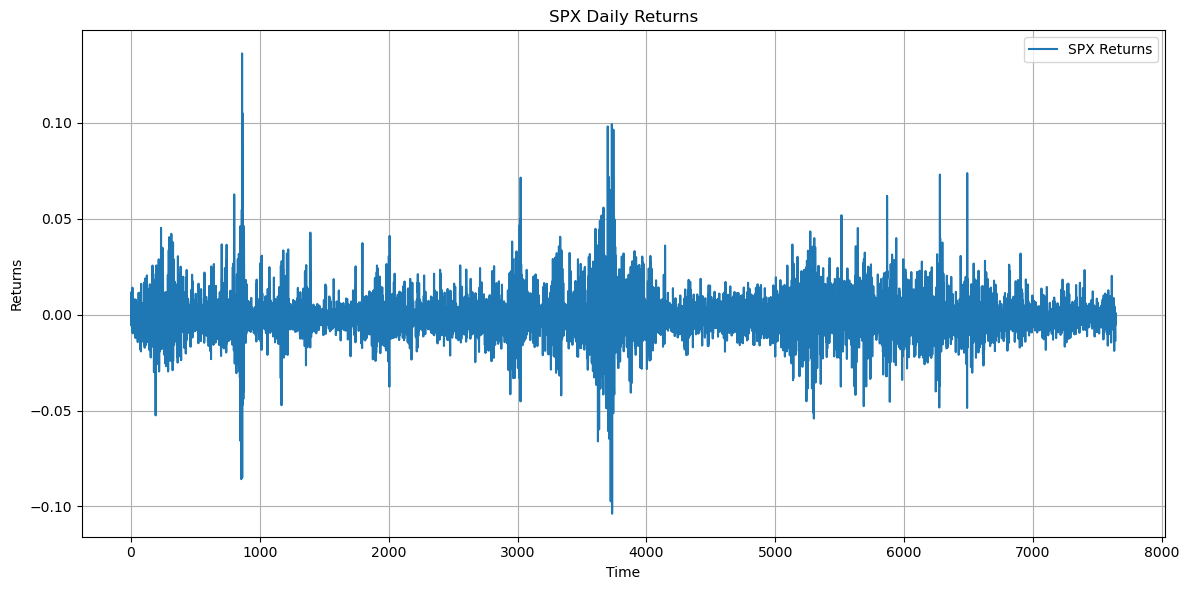

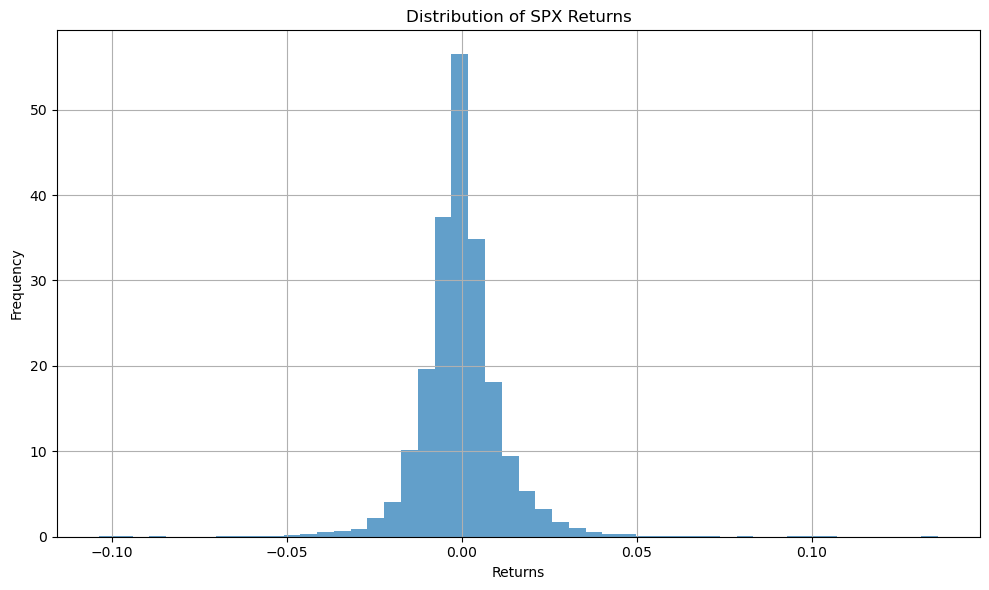

In [31]:
# Calculate returns for multiple assets
spx_returns = market['spx_adj_close'].pct_change().dropna()
jpm_returns = market['jpm_adj_close'].pct_change().dropna() 
jnj_returns = market['jnj_adj_close'].pct_change().dropna()
msft_returns = market['msft_adj_close'].pct_change().dropna()

# Visualize SPX returns
plt.figure(figsize=(12,6))
plt.plot(spx_returns, label='SPX Returns')
plt.title('SPX Daily Returns')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Show distribution of returns
plt.figure(figsize=(10,6))
plt.hist(spx_returns, bins=50, density=True, alpha=0.7)
plt.title('Distribution of SPX Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

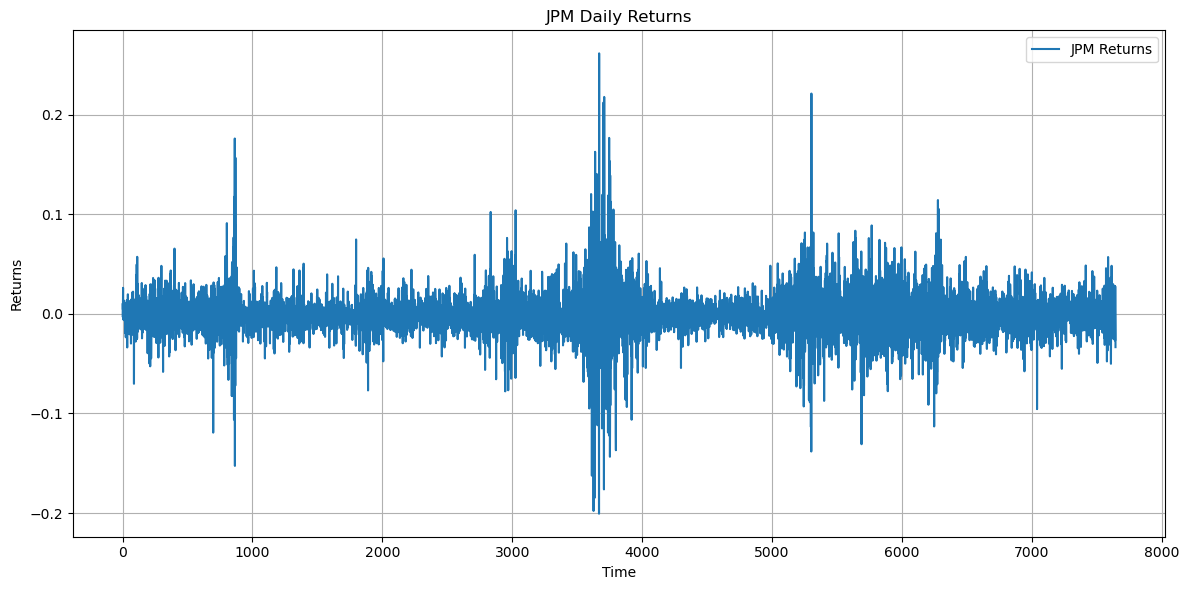

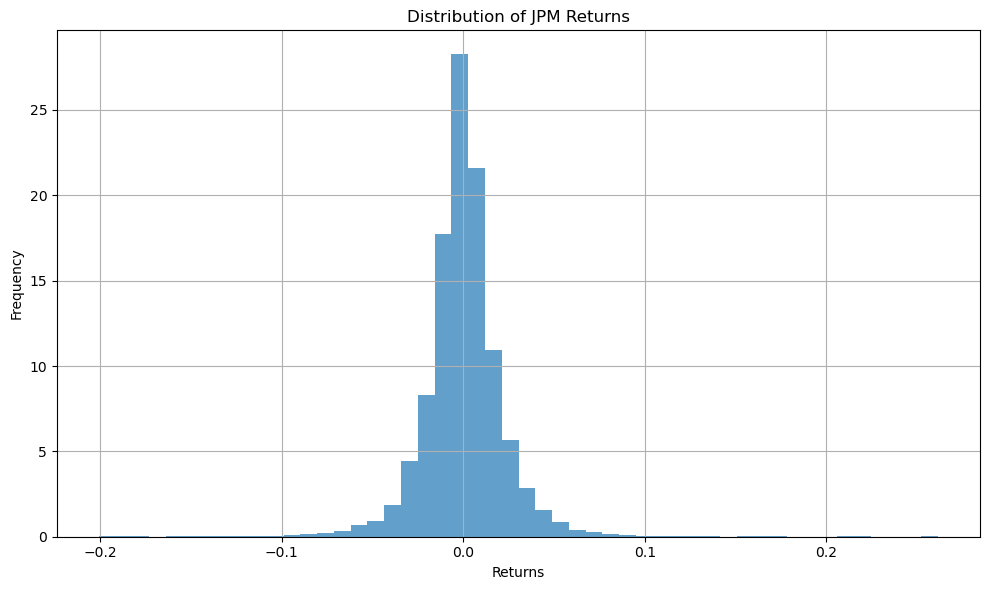

In [32]:
# Visualize JPM returns
plt.figure(figsize=(12,6))
plt.plot(jpm_returns, label='JPM Returns')
plt.title('JPM Daily Returns')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Show distribution of JPM returns 
plt.figure(figsize=(10,6))
plt.hist(jpm_returns, bins=50, density=True, alpha=0.7)
plt.title('Distribution of JPM Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()



Factor Model Posterior Parameters:
Beta Posterior Mean: -0.0009
Beta Posterior Std: 0.0243


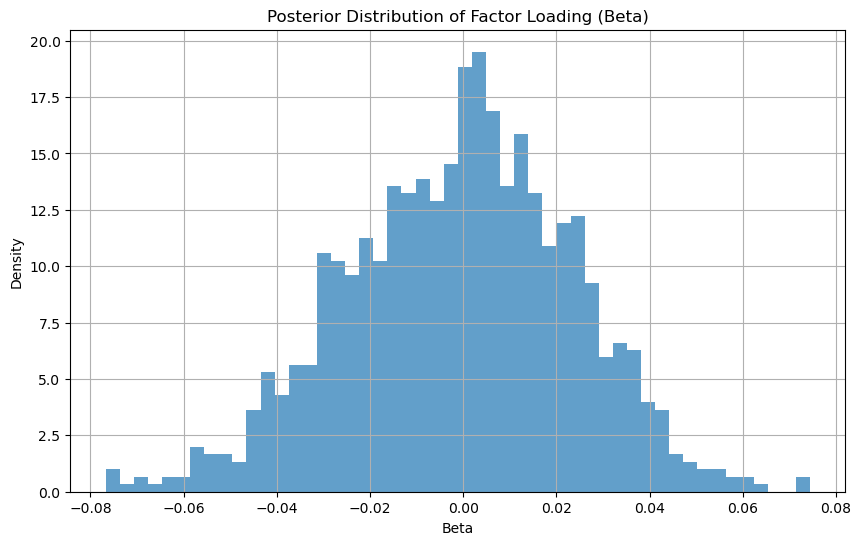

In [29]:
# Define likelihood function for returns using multivariate normal distribution
def log_likelihood(returns, mu, sigma):
    """
    Calculate log likelihood of returns under multivariate normal distribution
    
    Parameters:
    returns: observed returns
    mu: mean return
    sigma: volatility (standard deviation)
    """
    n = len(returns)
    # For single asset case, simplify multivariate normal to univariate
    log_like = -0.5 * n * np.log(2 * np.pi * sigma**2)
    log_like -= 0.5 * np.sum((returns - mu)**2) / sigma**2
    return log_like

# Define Bayesian Factor Model
class BayesianFactorModel:
    def __init__(self, returns, n_factors=1):
        self.returns = returns
        self.n_factors = n_factors
        self.T = len(returns)
        
        # Initialize factor loadings (beta) and factor returns
        self.beta = np.random.normal(0, 1, n_factors)
        self.factors = np.random.normal(0, 1, (self.T, n_factors))
        
        # Priors
        self.beta_prior_mean = 0
        self.beta_prior_var = 1
        self.factor_var_prior = 1
        self.idio_var_prior = 1
    
    def update_parameters(self, n_iterations=1000):
        """
        Update model parameters using Gibbs sampling
        """
        beta_samples = np.zeros(n_iterations)
        factor_samples = np.zeros((n_iterations, self.T))
        
        for i in range(n_iterations):
            # Update beta conditional on factors
            beta_var = 1 / (1/self.beta_prior_var + 
                          np.sum(self.factors**2)/self.idio_var_prior)
            beta_mean = beta_var * (self.beta_prior_mean/self.beta_prior_var + 
                                  np.sum(self.factors*self.returns)/self.idio_var_prior)
            self.beta = np.random.normal(beta_mean, np.sqrt(beta_var))
            
            # Update factors conditional on beta
            for t in range(self.T):
                factor_var = 1 / (self.beta**2/self.idio_var_prior + 
                                1/self.factor_var_prior)
                factor_mean = factor_var * (self.beta*self.returns[t]/self.idio_var_prior)
                self.factors[t] = np.random.normal(factor_mean, np.sqrt(factor_var))
            
            # Store samples
            beta_samples[i] = self.beta
            factor_samples[i] = self.factors.flatten()
            
        return beta_samples, factor_samples

# Initialize and fit the factor model
factor_model = BayesianFactorModel(spx_returns.values)
beta_samples, factor_samples = factor_model.update_parameters()

# Calculate posterior distributions
beta_posterior_mean = np.mean(beta_samples)
beta_posterior_std = np.std(beta_samples)

print("\nFactor Model Posterior Parameters:")
print(f"Beta Posterior Mean: {beta_posterior_mean:.4f}")
print(f"Beta Posterior Std: {beta_posterior_std:.4f}")

# Visualize beta posterior distribution
plt.figure(figsize=(10,6))
plt.hist(beta_samples, bins=50, density=True, alpha=0.7)
plt.title('Posterior Distribution of Factor Loading (Beta)')
plt.xlabel('Beta')
plt.ylabel('Density')
plt.grid(True)
plt.show()
